<h1>Mapping and plotting tools</h1>

<p>GeoPandas provides a high-level interface to the <a href="https://matplotlib.org/stable/">matplotlib</a> library for making maps. Mapping shapes is as easy as using the <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html" title="geopandas.GeoDataFrame.plot"><code>plot()</code></a> method on a
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.html" title="geopandas.GeoSeries"><code>GeoSeries</code></a> or
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html" title="geopandas.GeoDataFrame"><code>GeoDataFrame</code></a>.</p>

<p>Loading some example data:</p>

In [2]:
!pip install geopandas
!pip install geodatasets

In [3]:
import geopandas, geodatasets

In [4]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_commpop"))

Extracting 'chicago_commpop/chicago_commpop.geojson' from '/root/.cache/geodatasets/chicago_commpop.zip' to '/root/.cache/geodatasets/chicago_commpop.zip.unzip'


In [5]:
groceries = geopandas.read_file(geodatasets.get_path("geoda.groceries"))

Extracting 'grocery/chicago_sup.shp' from '/root/.cache/geodatasets/grocery.zip' to '/root/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.dbf' from '/root/.cache/geodatasets/grocery.zip' to '/root/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.shx' from '/root/.cache/geodatasets/grocery.zip' to '/root/.cache/geodatasets/grocery.zip.unzip'
Extracting 'grocery/chicago_sup.prj' from '/root/.cache/geodatasets/grocery.zip' to '/root/.cache/geodatasets/grocery.zip.unzip'


<p>You can now plot those GeoDataFrames:</p>

In [6]:
# Examine the chicago GeoDataFrame
chicago.head()

,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [44]:
# Basic plot, single color
import plotly.express as px

df = chicago
geojson = chicago.geometry

fig = px.choropleth(df, geojson=geojson, locations=df.index)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0})
fig.show()

# <h2>Choropleth maps</h2>

<p>Plotly makes it easy to create Choropleth maps (maps where the color of each shape is based on the value of an associated variable).
Simply use plotly express with the <code>color</code> argument set to the column whose values you want used to assign colors.</p>

In [48]:
# Plot by population
import plotly.express as px

df = chicago
geojson = chicago.geometry

fig = px.choropleth(df, geojson=geojson, locations=df.index, color=df.POP2010, color_continuous_scale='Viridis')
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0})
fig.update_layout(coloraxis_showscale=False)
fig.show()

## <h3>Creating a legend</h3>

<p>When plotting a map, one can enable a legend using the <code>coloraxis_showscale</code> argument:</p>

In [47]:
# Plot population estimates with an accurate legend
import plotly.express as px

df = chicago
geojson = chicago.geometry

fig = px.choropleth(df, geojson=geojson, locations=df.index, color=df.POP2010, color_continuous_scale='Viridis')
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0})
fig.update_layout(coloraxis_showscale=True)
fig.show()

<p>The following example plots the color bar below the map and adds its label using <code>fig.update_coloraxes</code>:</p>

In [62]:
# Plot population estimates with an accurate legend
import plotly.express as px

df = chicago
geojson = chicago.geometry

fig = px.choropleth(df, geojson=geojson, locations=df.index, color=df.POP2010, color_continuous_scale='Viridis')
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(margin={'r':0,'t':0,'l':0,'b':1})
fig.update_coloraxes(colorbar={'orientation':'h', 'y': -1.0})
fig.show()

<p>However, the default appearance of the legend and plot axes may not be desirable. One can define the plot axes (with <code>ax</code>) and the legend axes (with <code>cax</code>) and then pass those in to the
<a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html" title="geopandas.GeoDataFrame.plot"><code>plot()</code></a> call.
The following example uses <code>mpl_toolkits</code> to horizontally align the plot axes and the legend axes and change the width:</p>

<AxesSubplot: >

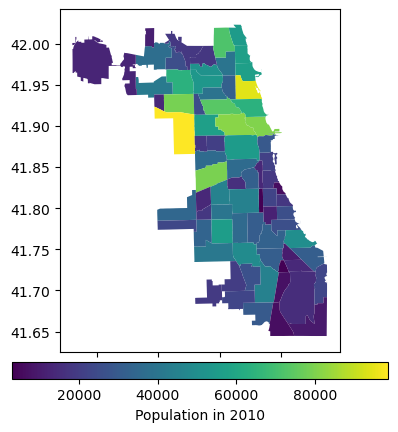

In [ ]:
# Plot population estimates with an accurate legend
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1)

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

chicago.plot(
    column="POP2010",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "Population in 2010", "orientation": "horizontal"},
)

## <h3>Choosing colors</h3>

<p>You can also modify the colors used by <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html" title="geopandas.GeoDataFrame.plot"><code>plot()</code></a> with the <code>cmap</code> option.
For a full list of colormaps, see <a href="https://matplotlib.org/stable/tutorials/colors/colormaps.html">Choosing Colormaps in Matplotlib</a>.</p>

<AxesSubplot: >

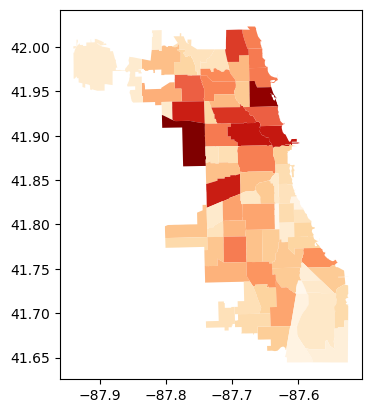

In [ ]:
chicago.plot(column='POP2010', cmap='OrRd')

<p>To make the color transparent for when you just want to show the boundary, you have two options. One option is to do <code>chicago.plot(facecolor="none", edgecolor="black")</code>. However, this can cause a lot of confusion because <code>"none"</code>  and <code>None</code> are different in the context of using <code>facecolor</code> and they do opposite things.
<code>None</code> does the “default behavior” based on matplotlib, and if you use it for <code>facecolor</code>, it actually adds a color.
The second option is to use <code>chicago.boundary.plot()</code>. This option is more explicit and clear.:</p>

<AxesSubplot: >

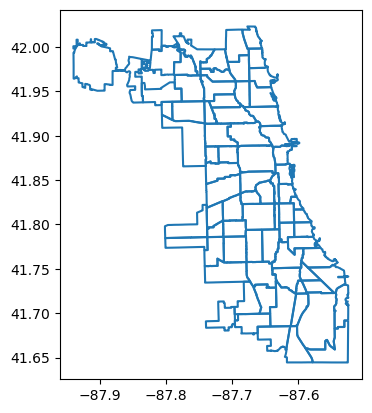

In [ ]:
chicago.boundary.plot()

<p>The way color maps are scaled can also be manipulated with the <code>scheme</code> option (if you have <code>mapclassify</code> installed, which can be accomplished via <code>conda install -c conda-forge mapclassify</code>). The <code>scheme</code> option can be set to any scheme provided by mapclassify (e.g. ‘box_plot’, ‘equal_interval’, ‘fisher_jenks’, ‘fisher_jenks_sampled’, ‘headtail_breaks’, ‘jenks_caspall’, ‘jenks_caspall_forced’, ‘jenks_caspall_sampled’, ‘max_p_classifier’, ‘maximum_breaks’, ‘natural_breaks’, ‘quantiles’, ‘percentiles’, ‘std_mean’ or ‘user_defined’). Arguments can be passed in classification_kwds dict. See the <a href="https://pysal.org/mapclassify">mapclassify documentation</a> for further details about these map classification schemes.</p>

<AxesSubplot: >

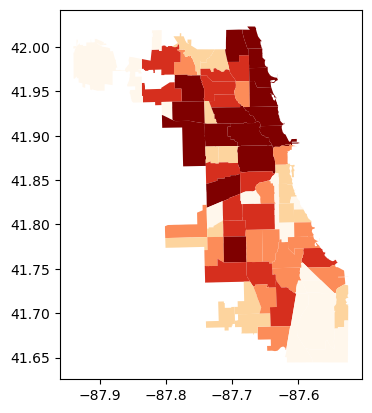

In [ ]:
chicago.plot(column='POP2010', cmap='OrRd', scheme='quantiles')

## <h3>Missing data</h3>

<p>In some cases one may want to plot data which contains missing values - for some features one simply does not know the value.
Geopandas (from the version 0.7) by defaults ignores such features.</p>

<AxesSubplot: >

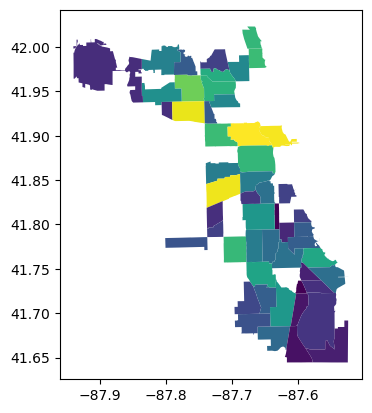

In [ ]:
import numpy as np

chicago.loc[np.random.choice(chicago.index, 30), 'POP2010'] = np.nan

chicago.plot(column='POP2010')

<p>However, passing <code>missing_kwds</code> one can specify the style and label of features containing None or NaN.</p>

<AxesSubplot: >

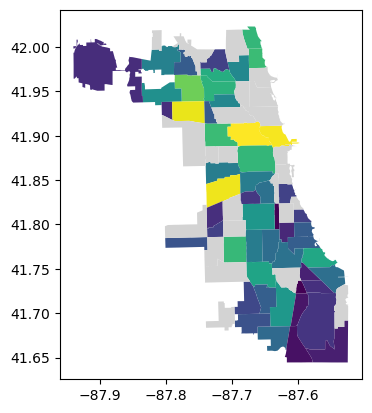

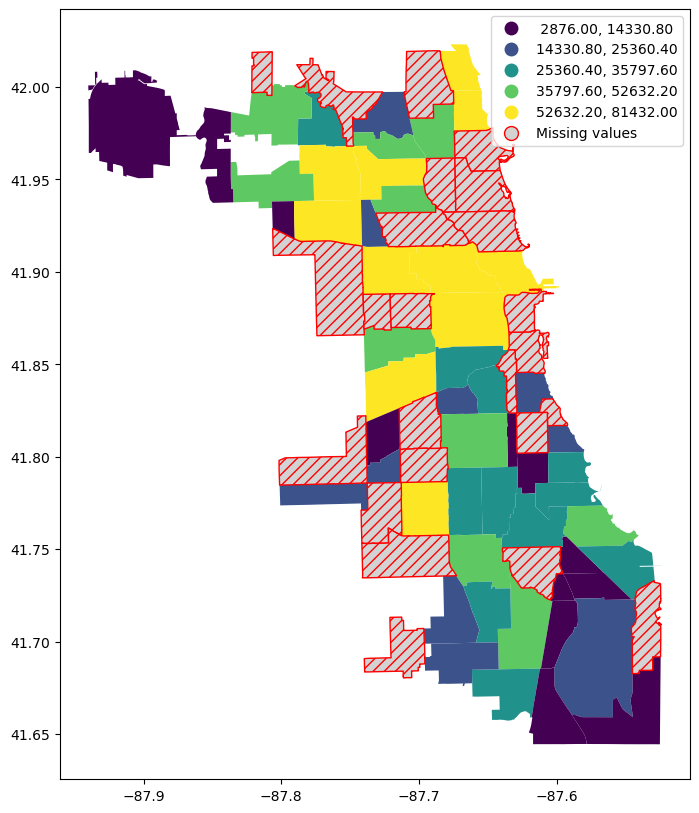

In [ ]:
chicago.plot(column='POP2010', missing_kwds={'color': 'lightgrey'})

chicago.plot(
    column="POP2010",
    legend=True,
    scheme="quantiles",
    figsize=(15, 10),
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    },
)

## <h3>Other map customizations</h3>

<p>Maps usually do not have to have axis labels. You can turn them off using <code>set_axis_off()</code> or <code>axis("off")</code> axis methods.</p>

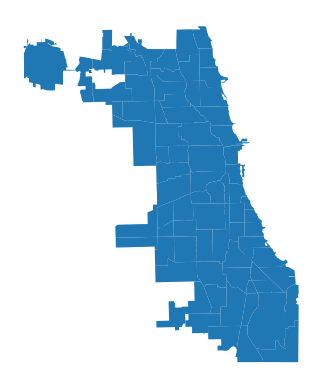

In [ ]:
ax = chicago.plot()

ax.set_axis_off()

# <h2>Maps with layers</h2>

<p>There are two strategies for making a map with multiple layers – one more succinct, and one that is a little more flexible.</p>

<p>Before combining maps, however, remember to always ensure they share a common CRS (so they will align).</p>

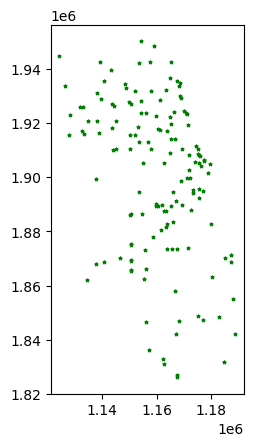

In [ ]:
# Look at capitals
# Note use of standard `pyplot` line style options
groceries.plot(marker='*', color='green', markersize=5)

# Check crs
groceries = groceries.to_crs(chicago.crs)

# Now you can overlay over the outlines

<p><strong>Method 1</strong></p>

<AxesSubplot: >

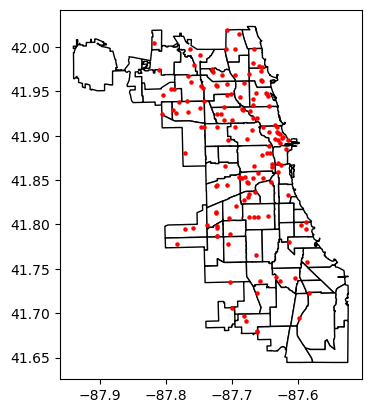

In [ ]:
base = chicago.plot(color='white', edgecolor='black')

groceries.plot(ax=base, marker='o', color='red', markersize=5)

<p><strong>Method 2: Using matplotlib objects</strong></p>

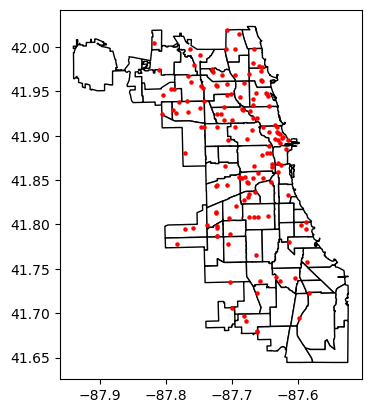

In [ ]:
fig, ax = plt.subplots()

chicago.plot(ax=ax, color='white', edgecolor='black')

groceries.plot(ax=ax, marker='o', color='red', markersize=5)

plt.show()

## <h3>Control the order of multiple layers in a plot</h3>

<p>When plotting multiple layers, use <code>zorder</code> to take control of the order of layers being plotted.
The lower the <code>zorder</code> is, the lower the layer is on the map and vice versa.</p>

<p>Without specified <code>zorder</code>, cities (Points) gets plotted below world (Polygons), following the default order based on geometry types.</p>

<AxesSubplot: >

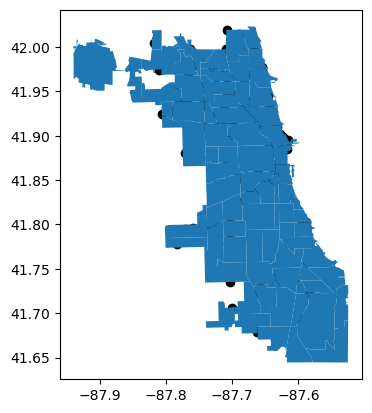

In [ ]:
ax = groceries.plot(color='k')

chicago.plot(ax=ax)

<p>You can set the <code>zorder</code> for cities higher than for world to move it of top.</p>

<AxesSubplot: >

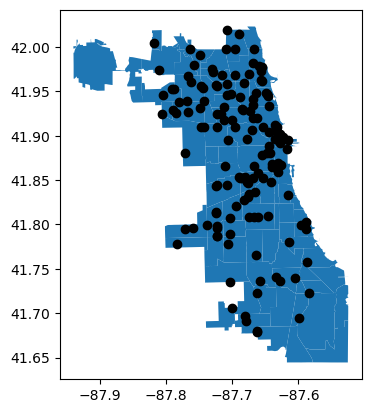

In [ ]:
ax = groceries.plot(color='k', zorder=2)

chicago.plot(ax=ax, zorder=1)

# <h2>Pandas plots</h2>

<p>Plotting methods also allow for different plot styles from pandas along with the default <code>geo</code> plot. These methods can be accessed using the <code>kind</code> keyword argument in <a href="https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html" title="geopandas.GeoDataFrame.plot"><code>plot()</code></a>, and include:</p>

<ul class="simple">
<li><p><code>geo</code> for mapping</p></li>
<li><p><code>line</code> for line plots</p></li>
<li><p><code>bar</code> or <code>barh</code> for bar plots</p></li>
<li><p><code>hist</code> for histogram</p></li>
<li><p><code>box</code> for boxplot</p></li>
<li><p><code>kde</code> or <code>density</code> for density plots</p></li>
<li><p><code>area</code>  for area plots</p></li>
<li><p><code>scatter</code> for scatter plots</p></li>
<li><p><code>hexbin</code> for hexagonal bin plots</p></li>
<li><p><code>pie</code> for pie plots</p></li>
</ul>

<AxesSubplot: xlabel='POP2010', ylabel='POP2000'>

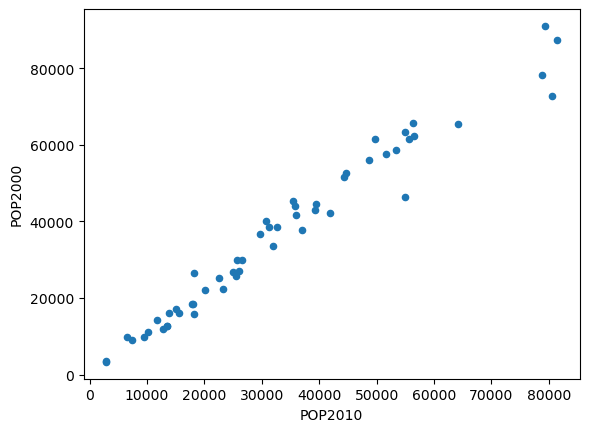

In [ ]:
chicago.plot(kind="scatter", x="POP2010", y="POP2000")

<p>You can also create these other plots using the <code>GeoDataFrame.plot.&lt;kind&gt;</code> accessor methods instead of providing the <code>kind</code> keyword argument.
For example, <code>hist</code>, can be used to plot histograms of population for two different years from the Chicago dataset.</p>

<AxesSubplot: ylabel='Frequency'>

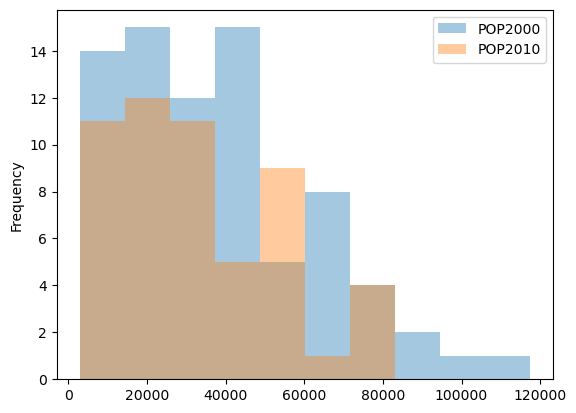

In [ ]:
chicago[["POP2000", "POP2010", "geometry"]].plot.hist(alpha=.4)

<p>For more information, see <a href="https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html">Chart visualization</a> in the pandas documentation.</p>

# <h2>Other resources</h2>

<p>Links to Jupyter Notebooks for different mapping tasks:</p>
<p><a href="http://nbviewer.jupyter.org/gist/perrygeo/c426355e40037c452434">Making Heat Maps</a></p>